##Import and Inspect the dataset

In [ ]:
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Mount Google Drive for file access (Colab-specific)
drive.mount('/content/drive')

# Define file path
train_file_path = '/content/drive/My Drive/Burnout/train.csv'

# Load dataset
train = pd.read_csv(train_file_path)
print(train.head())


print(f"\nThe train set consists of {len(train)} observations.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                Employee ID Date of Joining  Gender Company Type  \
0  fffe32003000360033003200      2008-09-30  Female      Service   
1      fffe3700360033003500      2008-11-30    Male      Service   
2  fffe31003300320037003900      2008-03-10  Female      Product   
3  fffe32003400380032003900      2008-11-03    Male      Service   
4  fffe31003900340031003600      2008-07-24  Female      Service   

  WFH Setup Available  Designation  Resource Allocation  Mental Fatigue Score  \
0                  No          2.0                  3.0                   3.8   
1                 Yes          1.0                  2.0                   5.0   
2                 Yes          2.0                  NaN                   5.8   
3                 Yes          1.0                  1.0                   2.6   
4                  No          3.0                  7.0  

In [ ]:
# Check for null values
train.isna().sum()

,0
Employee ID,0
Date of Joining,0
Gender,0
Company Type,0
WFH Setup Available,0
Designation,0
Resource Allocation,1381
Mental Fatigue Score,2117
Burn Rate,1124


## Handling missing values


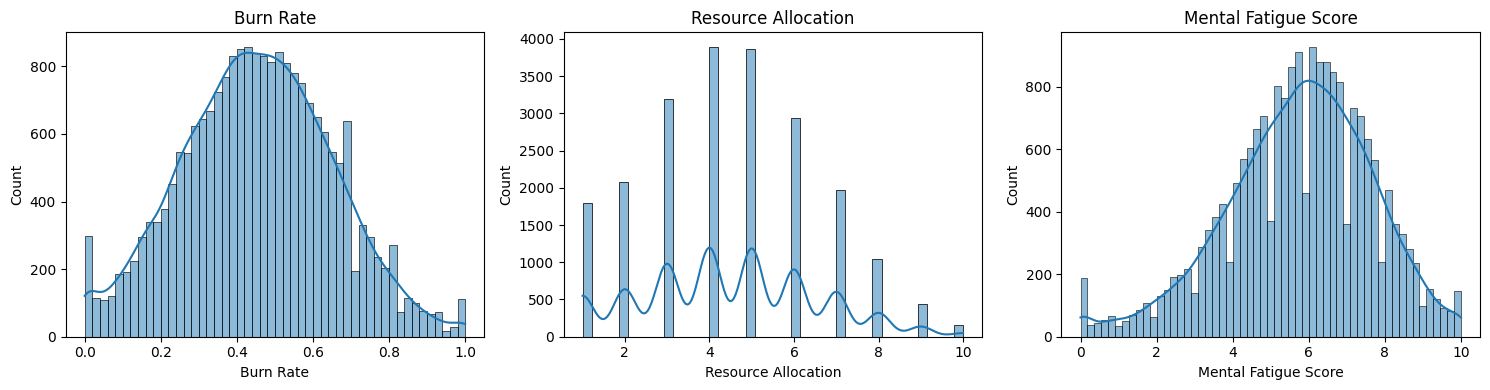

In [ ]:
# Check the distributions for the features of missing values
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(data=train, x="Burn Rate", kde=True, ax=axs[0])
axs[0].set_title("Burn Rate")

sns.histplot(data=train, x="Resource Allocation", kde=True, ax=axs[1])
axs[1].set_title("Resource Allocation")

sns.histplot(data=train, x="Mental Fatigue Score", kde=True, ax=axs[2])
axs[2].set_title("Mental Fatigue Score")

plt.tight_layout()
plt.show()

It seems that Burn Rate and Mental Fatige Score approach the Normal Distribution, but with some extreme values on the tails. Resource allocation is multimodal. Since Burn Rate is the target variable, missing values will be dropped. Moreover, the same will apply for Resource Allocation and Mental Fatigue Score, since it is not safe to use data imputation in this occasion.

In [ ]:
# Drop null values for Burn Rate
train = train.dropna()
print(train.isna().sum())

# Print the current number of observations
print(f"\nThe current number of observations after dropping nulls is: {len(train)}")

Employee ID             0
Date of Joining         0
Gender                  0
Company Type            0
WFH Setup Available     0
Designation             0
Resource Allocation     0
Mental Fatigue Score    0
Burn Rate               0
dtype: int64

The current number of observations after dropping nulls is: 18590


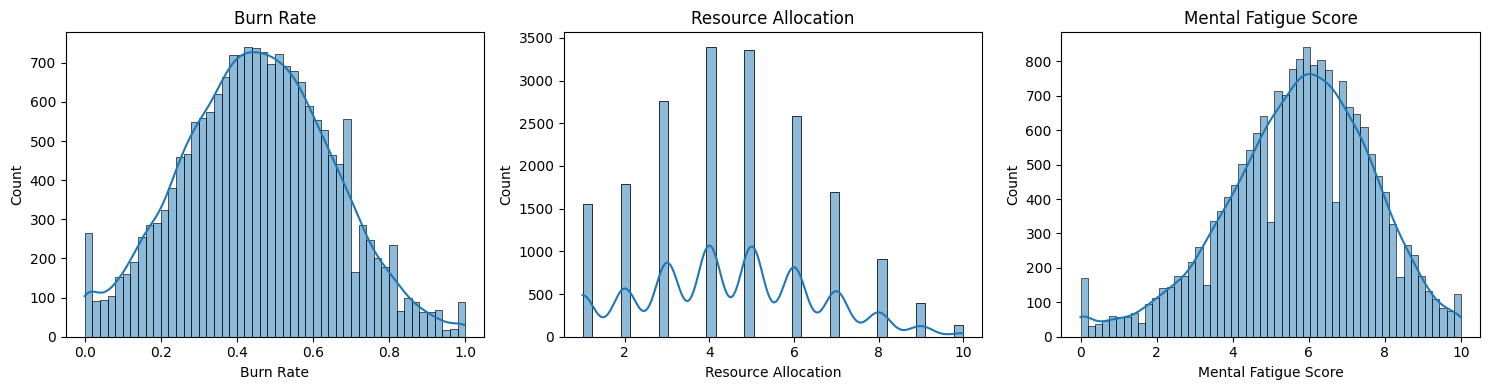

In [ ]:
# Check the distributions for the same features after dropping missing values
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(data=train, x="Burn Rate", kde=True, ax=axs[0])
axs[0].set_title("Burn Rate")

sns.histplot(data=train, x="Resource Allocation", kde=True, ax=axs[1])
axs[1].set_title("Resource Allocation")

sns.histplot(data=train, x="Mental Fatigue Score", kde=True, ax=axs[2])
axs[2].set_title("Mental Fatigue Score")

plt.tight_layout()
plt.show()

In [ ]:
train.describe()

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
count,18590.000000,18590.000000,18590.000000,18590.000000
mean,2.179398,4.486552,5.732173,0.452444
std,1.133148,2.044848,1.920547,0.197848
min,0.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,4.600000,0.320000
50%,2.000000,4.000000,5.900000,0.450000
75%,3.000000,6.000000,7.100000,0.590000
max,5.000000,10.000000,10.000000,1.000000


## Print the a combined figure of the plots above

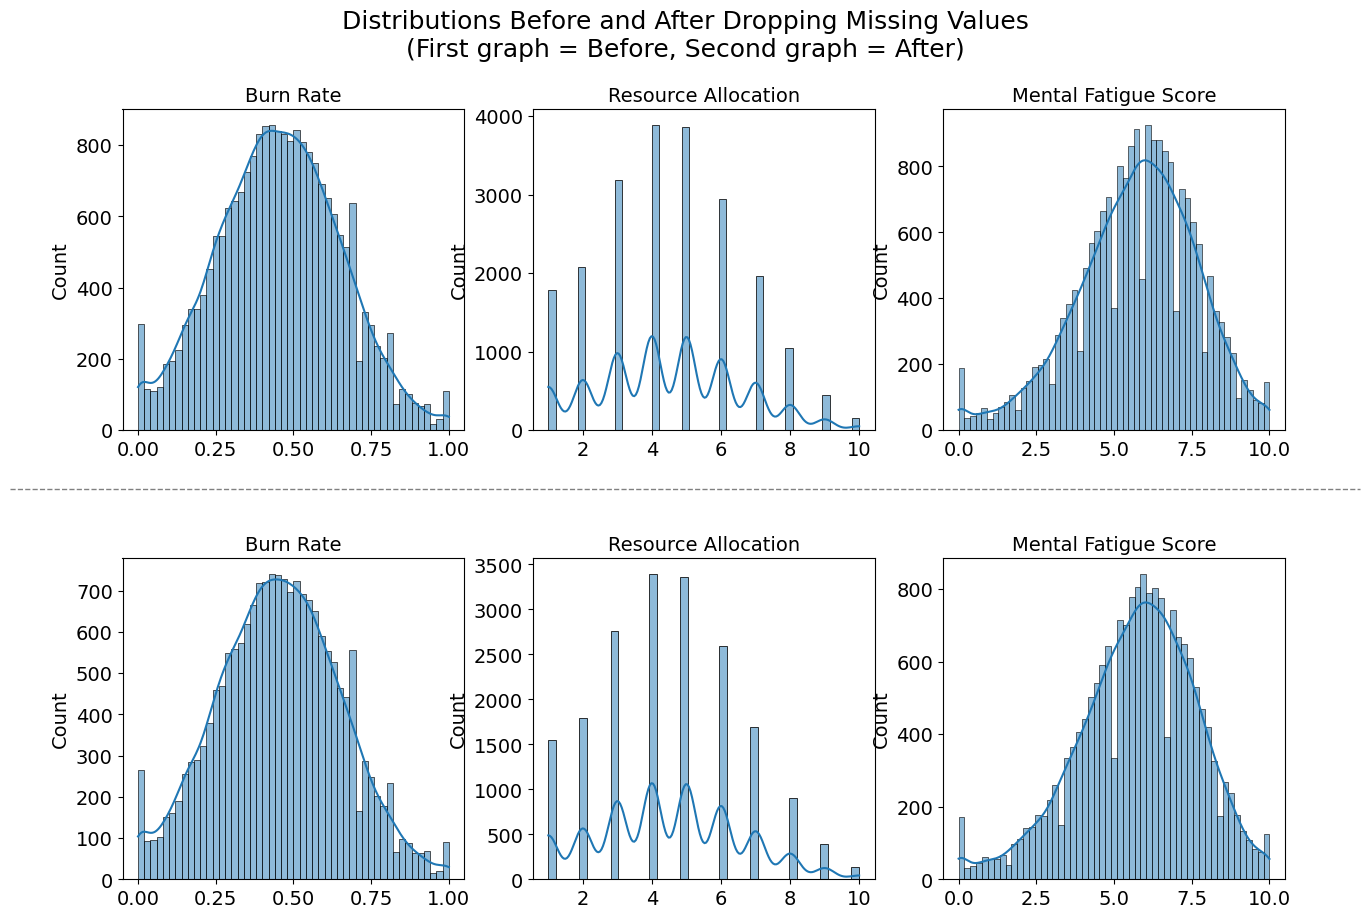

In [ ]:
from matplotlib import gridspec

# Load and prepare data
copy_train = pd.read_csv(train_file_path)
train_before = copy_train.copy()
train_after = copy_train.copy().dropna()

# Create figure with GridSpec
fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1], hspace=0.4)  # Equal row spacing

# Main title (keep bigger font)
fig.suptitle('Distributions Before and After Dropping Missing Values\n(First graph = Before, Second graph = After)',
             fontsize=18, y=0.98)

# Function to make plots with consistent formatting
def plot_hist(data, column, ax, title):
    sns.histplot(data=data, x=column, kde=True, ax=ax)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("")  # remove x-axis label
    ax.set_ylabel("Count", fontsize=14)
    ax.tick_params(axis='both', labelsize=14)

# First row (Before dropping)
plot_hist(train_before, "Burn Rate", fig.add_subplot(gs[0, 0]), "Burn Rate")
plot_hist(train_before, "Resource Allocation", fig.add_subplot(gs[0, 1]), "Resource Allocation")
plot_hist(train_before, "Mental Fatigue Score", fig.add_subplot(gs[0, 2]), "Mental Fatigue Score")

# Second row (After dropping)
plot_hist(train_after, "Burn Rate", fig.add_subplot(gs[1, 0]), "Burn Rate")
plot_hist(train_after, "Resource Allocation", fig.add_subplot(gs[1, 1]), "Resource Allocation")
plot_hist(train_after, "Mental Fatigue Score", fig.add_subplot(gs[1, 2]), "Mental Fatigue Score")

# Horizontal divider line between rows
fig.add_artist(plt.Line2D([0.05, 0.95], [0.5, 0.5],
                          color="gray", linewidth=1, linestyle="--",
                          transform=fig.transFigure))

# Save and show
plt.savefig("distributions_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

## Check if all Employee ID values are unique

In [ ]:
# Check if 'Employee ID' has all unique values
print("Employee ID all unique? →", train['Employee ID'].is_unique)

Employee ID all unique? → True


## Preprocess the Date of Joining
Date of Joining will converted to a column called "Tenure", which will be measured in years. To do this, the date will be substructed from the base month and year of prediction (October, 2020).

In [ ]:
# Parse the dates
train["Date of Joining"] = pd.to_datetime(train["Date of Joining"])

# Pull out year & month into integer columns
join_year  = train["Date of Joining"].dt.year
join_month = train["Date of Joining"].dt.month

# Define the reference year & month (October 2020)
ref_year, ref_month = 2020, 10

# Compute months of tenure, then convert to years
train["Tenure"] = ((ref_year - join_year) * 12 + (ref_month - join_month)) / 12

# Drop the original column Date of Joining, as well as the Employee ID
train = train.drop(columns=["Employee ID", "Date of Joining"])
print(train.head())

   Gender Company Type WFH Setup Available  Designation  Resource Allocation  \
0  Female      Service                  No          2.0                  3.0   
1    Male      Service                 Yes          1.0                  2.0   
2  Female      Product                 Yes          2.0                  NaN   
3    Male      Service                 Yes          1.0                  1.0   
4  Female      Service                  No          3.0                  7.0   

   Mental Fatigue Score  Burn Rate     Tenure  
0                   3.8       0.16  12.083333  
1                   5.0       0.36  11.916667  
2                   5.8       0.49  12.583333  
3                   2.6       0.20  11.916667  
4                   6.9       0.52  12.250000  


## Scatterplots of features in respect to the target variable (Burn Rate)

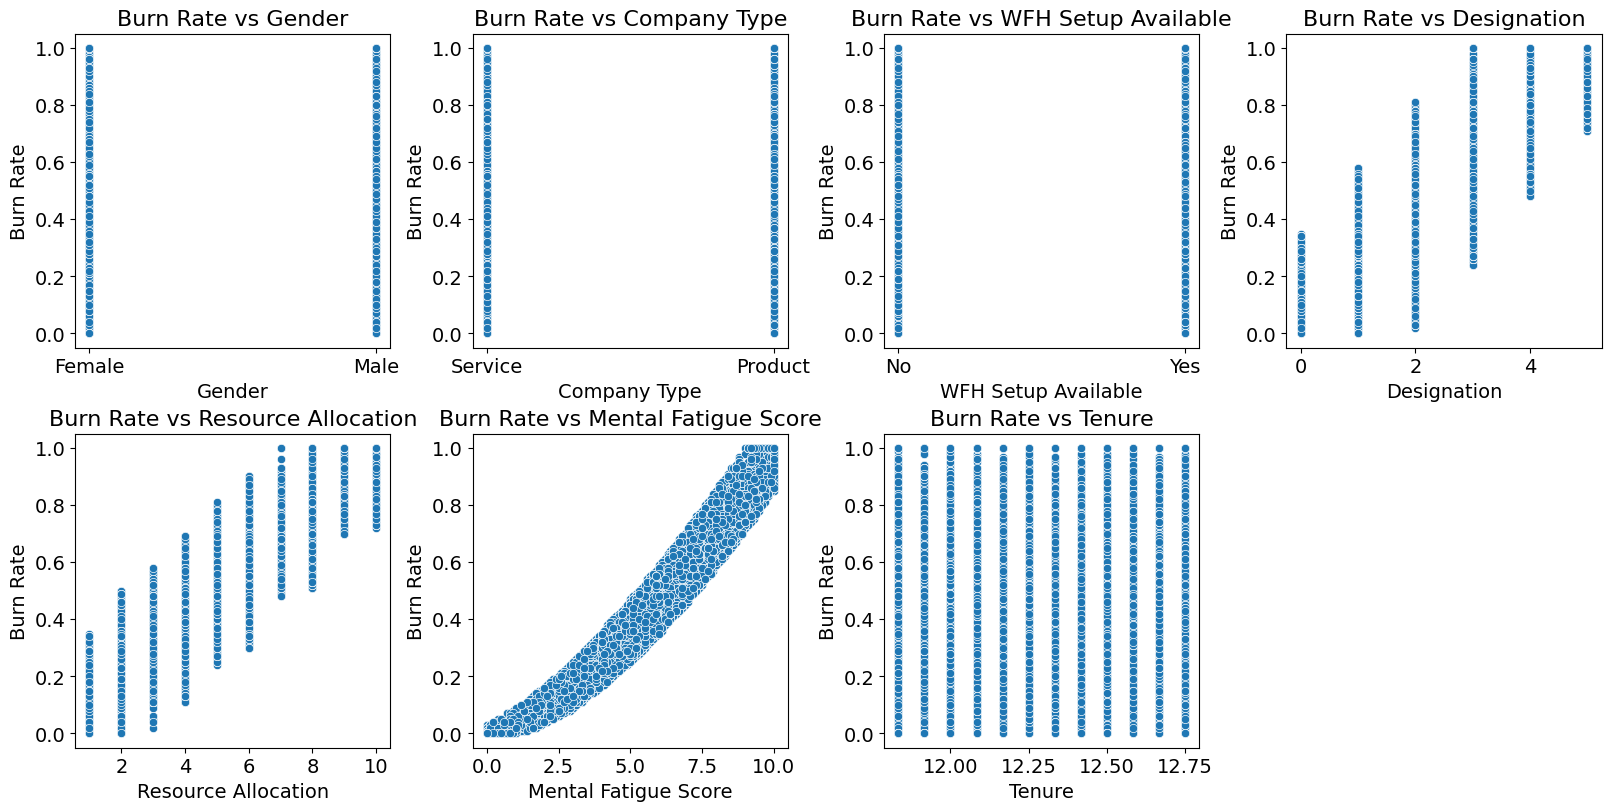

In [ ]:
# Get the feature list (everything except the target)
features = train.columns.drop("Burn Rate").tolist()

# To print on 4 plots per row
ncols = 4
nrows = math.ceil(len(features) / ncols)

# Make the canvas --> each subplot (4×4)
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(ncols * 4, nrows * 4),
    constrained_layout=True
)

# Loop through and draw
for idx, col in enumerate(features):
    ax = axes.flatten()[idx]
    sns.scatterplot(data=train, x=col, y="Burn Rate", ax=ax)
    ax.set_title(f"Burn Rate vs {col}", fontsize=16)   # title fontsize
    ax.set_xlabel(col, fontsize=14)                   # x-axis label fontsize
    ax.set_ylabel("Burn Rate", fontsize=14)           # y-axis label fontsize
    ax.tick_params(axis='both', labelsize=14)         # tick fontsize

# Turn off any unused axes
for ax in axes.flatten()[len(features):]:
    ax.set_visible(False)

# Save the figure
plt.savefig("burn_rate_scatterplots.png", dpi=300, bbox_inches='tight')

plt.show()

It is clear that binary variables (Gender, Company Type, WFH Available) are almost equally allocated and don't give any insight for now. The same applies for Tenure, probably because all the employee dates of joining include 2008, giving no explanatory power in burn rates.
On the other hand, designation and resource allocation indicate a positive correlation with burnout. This means that more senior positions and higher workloads are associated with higher burnout intensity.
Finally, Mental Fatigue clearly has a positive effect on burnout, as indicated from the scatterplot.

## Correlation Matrix of the features
While scatterplots are a good way to have a first look for potential patterns, the correlation matrix is very useful as well to check for the relationships between the features.

Index(['Gender', 'Company Type', 'WFH Setup Available'], dtype='object')
Designation                float64
Resource Allocation        float64
Mental Fatigue Score       float64
Burn Rate                  float64
Tenure                     float64
WFH Setup Available_Yes       bool
Gender_Male                   bool
Company Type_Service          bool
dtype: object


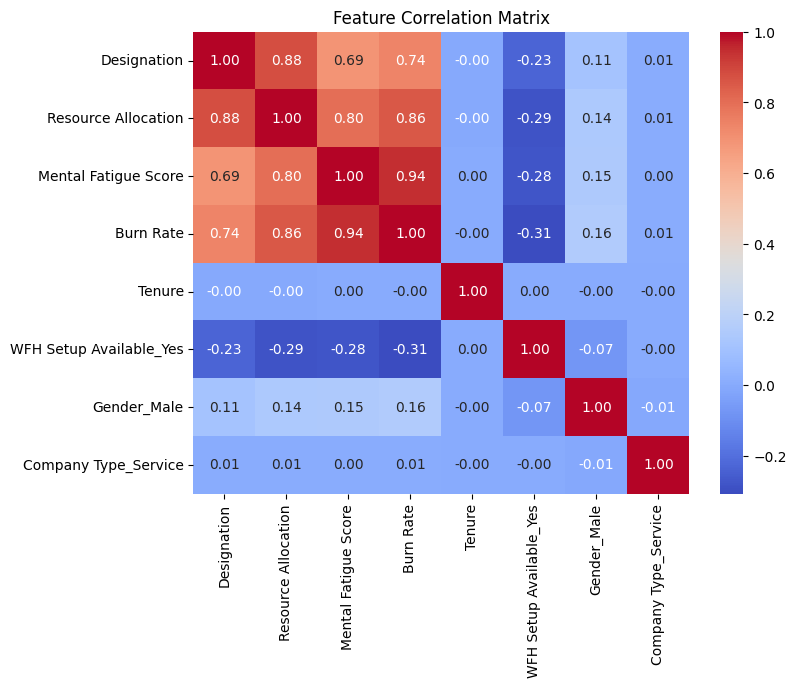

In [ ]:
# Inspect which columns are still object‐dtype
print(train.select_dtypes(include=['object']).columns)


# One‐hot encode the remaining noms
train = pd.get_dummies(
    train,
    columns=['WFH Setup Available','Gender','Company Type'],
    drop_first=True                     # To avoid collinearity due to the potential dummy trap
)

# Check if all columns are numeric
print(train.dtypes)

# Compute correlation matrix and then plot
corr = train.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.savefig("burn_corr_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

It is clear that Tenure does not correlate with any of the features, aligining with our intuition from the scatter plots. For this reason it will be dropped from the dataset. Likewise, Company Type has almost zero correlation with all the other features, but it will be kept. The higher correlation with Burn Rates is indicated by Mental Fatigue Score at 0.94, followed by Resource Allocation and Designation at 0.86 and 0.74, respectively.

In [ ]:
# Drop Tenure
train.drop(columns=['Tenure'], inplace=True)

train.describe()

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
count,18590.000000,18590.000000,18590.000000,18590.000000
mean,2.179398,4.486552,5.732173,0.452444
std,1.133148,2.044848,1.920547,0.197848
min,0.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,4.600000,0.320000
50%,2.000000,4.000000,5.900000,0.450000
75%,3.000000,6.000000,7.100000,0.590000
max,5.000000,10.000000,10.000000,1.000000


In [ ]:
print(train.head())

   Designation  Resource Allocation  Mental Fatigue Score  Burn Rate  \
0          2.0                  3.0                   3.8       0.16   
1          1.0                  2.0                   5.0       0.36   
3          1.0                  1.0                   2.6       0.20   
4          3.0                  7.0                   6.9       0.52   
5          2.0                  4.0                   3.6       0.29   

   WFH Setup Available_Yes  Gender_Male  Company Type_Service  
0                    False        False                  True  
1                     True         True                  True  
3                     True         True                  True  
4                    False        False                  True  
5                     True         True                 False  


The Burnout Dataset is now ready for training. The next step is to save it and use the updated file (new_train.csv) for our Machine Learning model comparison.

In [ ]:
# Save the train dataset to csv
train.to_csv('new_train.csv', index=False)